In [34]:
import numpy as np
import pandas as pd
import torch
import glob
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import os, sys
helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

### Signal Validation

In [35]:
def load_signal_data(directory_path):

    signal_df = {}
    # Check if directory exists to avoid errors
    if not os.path.exists(directory_path):
        print(f"Warning: Directory '{directory_path}' not found.")

    print(f"--- Loading from: {directory_path} ---")

    for filename in os.listdir(directory_path):
        if filename.endswith("markIII.txt"):

            parts = filename.replace('markIII.txt', '').split('_')
            print(filename)
            try:
                mass_val = int(parts[0])
                lambda_val = int(parts[1])
                
                # Load Data
                file_path = os.path.join(directory_path, filename)
                df = pd.read_csv(file_path, delim_whitespace=True)

                # Add Physics Parameters to DataFrame
                signal_df[f"{mass_val}_{lambda_val}"] = df
                    
            except (ValueError, IndexError) as e:
                print(f"Skipping malformed file: {filename} ({e})")
    print(f"Loaded {len(signal_df)} files.")
    
    return signal_df

# ==========================================
# 1. Load "No Cut" Signals (NC)
# ==========================================
# Update path to where your 'final_signals_nc' folder actually is
# dir_nc = 'final_signals_no_muons_nc' 
dir_nc = 'replicate_deepak_nc'
signals_nc = load_signal_data(dir_nc)

# ==========================================
# 2. Load "With Cut" Signals (Cut)
# ==========================================
# Update path to where your 'final_signals' folder is
# dir_cuts = 'final_signals'
# dir_cuts = 'final_signals_no_muons'
dir_cuts = 'replicate_deepak'
signals_cut = load_signal_data(dir_cuts)

--- Loading from: replicate_deepak_nc ---
1000_8_events_markIII.txt
3000_4_events_markIII.txt
2000_6_events_markIII.txt
3000_2_events_markIII.txt
1000_6_events_markIII.txt
2000_4_events_markIII.txt
Loaded 6 files.
--- Loading from: replicate_deepak ---
1000_8_events_markIII.txt
3000_4_events_markIII.txt
2000_6_events_markIII.txt
3000_2_events_markIII.txt
1000_6_events_markIII.txt
2000_4_events_markIII.txt
Loaded 6 files.


In [36]:
signals_nc.keys(), signals_cut.keys()  # Verify loaded signals

(dict_keys(['1000_8', '3000_4', '2000_6', '3000_2', '1000_6', '2000_4']),
 dict_keys(['1000_8', '3000_4', '2000_6', '3000_2', '1000_6', '2000_4']))

In [37]:
# =========================================================
# CONFIGURATION
# =========================================================
# Set your luminosity here (e.g., 139 for 139 fb^-1, or 1 if weights are already scaled)
LUMINOSITY = 139

# Define a dictionary or function for your Cross Sections (sigma)
# Format: {(Mass, Lambda): Cross_Section_Value}
# YOU MUST FILL THIS IN with your actual physics values
xsec_map = {
    (1000, 2): 9551,
    (1000, 4): 9540,
    (1000, 6): 9552,
    (1000, 8): 9554,
    (2000, 2): 146.3,
    (2000, 4): 146.8,
    (2000, 6): 146.1,
    (2000, 8): 145.3,
    (3000, 2): 14.24,
    (3000, 4): 14.2,
    (3000, 6): 14.21,
    (3000, 8): 14.26
}

def get_cross_section(m, l):
    """Returns cross section for mass m and lambda l. Defaults to 1.0 if missing."""
    return xsec_map.get((m, l), 1.0) 

# =========================================================
# PROCESSING LOGIC
# =========================================================
rows = []

for signal_mode in signals_nc.keys():
    
    # 1. Initial Events (Sum of weights in NC file)
    initial_events = signals_nc[signal_mode]['weight'].sum()

    
    # Initialize default values in case matching cut file is missing
    n_cut1 = 0
    n_cut2 = 0
    cut1_eff = 0.0
    cut2_eff = 0.0
    
    
    df_cut1 = signals_cut[signal_mode]

    n_cut1 = df_cut1['weight'].sum()

    if 'ht' in df_cut1.columns and 'met' in df_cut1.columns:
        mask_cut2 = (df_cut1['ht'] > 600) & (df_cut1['met'] > 600)
        n_cut2 = df_cut1.loc[mask_cut2, 'weight'].sum()
    else:
        print(f"Warning: 'ht' or 'met' missing in {signal_mode}")

    # 4. Efficiencies
    # Avoid division by zero
    if initial_events > 0:
        cut1_eff = n_cut1 / initial_events
        cut2_eff = n_cut2 / initial_events

    mass, lam = signal_mode.split('_')
    mass = int(mass)
    lam = int(lam)
    
    xsec = get_cross_section(mass, lam)
 
    exp_initial = LUMINOSITY * xsec 
    exp_cut1 = LUMINOSITY * xsec * cut1_eff
    exp_cut2 = LUMINOSITY * xsec * cut2_eff
    
    # Append row
    rows.append({
        'Mass': mass,
        'Lambda': lam,
        'Initial Events': initial_events,
        '1st Cut': n_cut1,
        '2nd Cut': n_cut2,
        '1st Cut Efficiency': cut1_eff,
        '2nd Cut Efficiency': cut2_eff,
        'Cross Section': xsec,
        'Initial Expected Events': exp_initial,
        '1st Cut Expected Events': exp_cut1,
        '2nd Cut Expected Events': exp_cut2
    })

# Create DataFrame for this detector
df_summary = pd.DataFrame(rows)

In [38]:
df_summary.sort_values(by=['Mass'], inplace=True)
sorted_keys = sorted(signals_cut.keys())

# 2. Rebuild the dictionary in that order
signals_cut = {k: signals_cut[k] for k in sorted_keys}

In [39]:
df_summary

,Mass,Lambda,Initial Events,1st Cut,2nd Cut,1st Cut Efficiency,2nd Cut Efficiency,Cross Section,Initial Expected Events,1st Cut Expected Events,2nd Cut Expected Events
0,1000,8,9.105032e+06,3.022376e+06,507631.280800,0.331946,0.055753,9554.00,1328006.00,440825.794784,74040.087996
4,1000,6,9.102617e+06,4.320905e+06,529463.885300,0.474688,0.058166,9552.00,1327728.00,630256.808181,77228.784748
2,2000,6,1.328580e+05,4.791664e+04,23407.884300,0.360661,0.176187,146.10,20307.90,7324.258201,3577.992836
5,2000,4,1.337954e+05,5.400179e+04,18176.028300,0.403615,0.135849,146.80,20405.20,8235.839457,2772.035235
1,3000,4,9.158195e+03,1.335367e+03,471.534512,0.145811,0.051488,14.20,1973.80,287.801976,101.626448
3,3000,2,9.171551e+03,1.567496e+03,250.269110,0.170908,0.027288,14.24,1979.36,338.289445,54.011877


### Signal Improvement  

In [40]:
# --- Configuration ---
MC_PATH = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/data/mc_events_chunk03.npz"        # UPDATE THIS
SCALER_PATH = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers/mc_scaler_chunk03.pkl"    # UPDATE THIS
MODEL_BASE_PATH = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/eval_sr"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURE_COLS = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
N_CONTEXT = 2

In [41]:
def load_background_and_scaler():
    """Loads the background MC data and the scaler used for training."""
    # Load Background (Class 0)
    bg_data = np.load(MC_PATH, allow_pickle=True)["mc_events_sr"]
    
    # Load Scaler
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)
        
    return bg_data, scaler

def calculate_max_sic(y_true, y_scores, bkg_eff_cutoff=1e-3):
    """Calculates Max Significance Improvement Characteristic."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        sic = tpr / np.sqrt(fpr)
    
    # Filter for valid range (e.g., FPR > cutoff to avoid spikes at 0)
    mask = fpr > bkg_eff_cutoff
    if np.any(mask):
        return np.nanmax(sic[mask])
    return 0.0

def prepare_test_data(df_signal, bg_data, scaler, apply_sr_mask=True):
    feature_cols = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
    
    # 2. Filter & Mask Signal Data
    if apply_sr_mask:
        mask = (df_signal['ht'] > 600) & (df_signal['met'] > 600)
        df_masked = df_signal[mask]
    else:
        df_masked = df_signal

    # 3. Extract raw numpy array
    if df_masked.empty:
        print("   ⚠️ Warning: No signal events passed the SR cuts!")
        return None, None
        
    sig_raw = df_masked[feature_cols].to_numpy()
    sig_scaled = scaler.transform(sig_raw)
    X_test = np.vstack((bg_data, sig_scaled))
    y_bg = np.zeros(len(bg_data))
    y_sig = np.ones(len(sig_scaled))
    y_test = np.concatenate((y_bg, y_sig))
    
    print(f"   Shape check: Signal (Raw): {len(df_signal)} -> (Masked): {len(df_masked)}")
    
    return X_test, y_test

def plot_feature_comparison(bg_data_scaled, df_signal, scaler, signal_label="Signal (1000, 2)"):

    feature_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]
    # --- 1. Prepare Signal Data ---
    # Apply SR Cuts (HT > 600, MET > 600)
    mask = (df_signal['ht'] > 600) & (df_signal['met'] > 600)
    sig_raw = df_signal.loc[mask, feature_names].to_numpy()
    
    if len(sig_raw) == 0:
        print("No signal events passed the cuts.")
        return

    # --- 2. Prepare Background Data ---
    # We assume bg_data_scaled is already scaled. 
    # To compare apples-to-apples in PHYSICAL units, we inverse transform the background.
    # To compare in NETWORK units, we transform the signal.
    # Let's do PHYSICAL units (more interpretable).
    
    try:
        bg_physical = scaler.inverse_transform(bg_data_scaled)
        # print(bg_physical.shape)
        sig_physical = sig_raw # Already physical
        print("Plotting in PHYSICAL units (Inverse Scaled).")
        unit_status = "Physical Units"
    except Exception as e:
        # Fallback: If inverse_transform fails, plot in Scaled units
        print(f"Inverse transform failed ({e}). Plotting in SCALED units.")
        bg_physical = bg_data_scaled
        sig_physical = scaler.transform(sig_raw)
        unit_status = "Scaled Units"

    fig, axes = plt.subplots(1, len(feature_names), figsize=(25, 5))
    axes = axes.flatten()

    for i, feature in enumerate(feature_names):
        ax = axes[i]
        
        # Get data for this feature column
        bg_col = bg_physical[:, i]
        sig_col = sig_physical[:, i]
        
        # Determine nice bin range
        # focusing on the bulk of data (1st to 99th percentile) to avoid outliers squashing the plot
        low = min(np.percentile(bg_col, 1), np.percentile(sig_col, 1))
        high = max(np.percentile(bg_col, 99), np.percentile(sig_col, 99))
        bins = np.linspace(low, high, 40)
        
        # Plot Background
        ax.hist(bg_col, bins=bins, density=True, alpha=0.6, 
                label='Background', color='tab:blue', histtype='stepfilled')
        
        # Plot Signal (Step style for visibility)
        ax.hist(sig_col, bins=bins, density=True, linewidth=2,
                label=signal_label, color='tab:orange', histtype='step')
        
        ax.set_title(feature)
        ax.set_xlabel(unit_status)
        ax.legend()
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

Plotting in PHYSICAL units (Inverse Scaled).


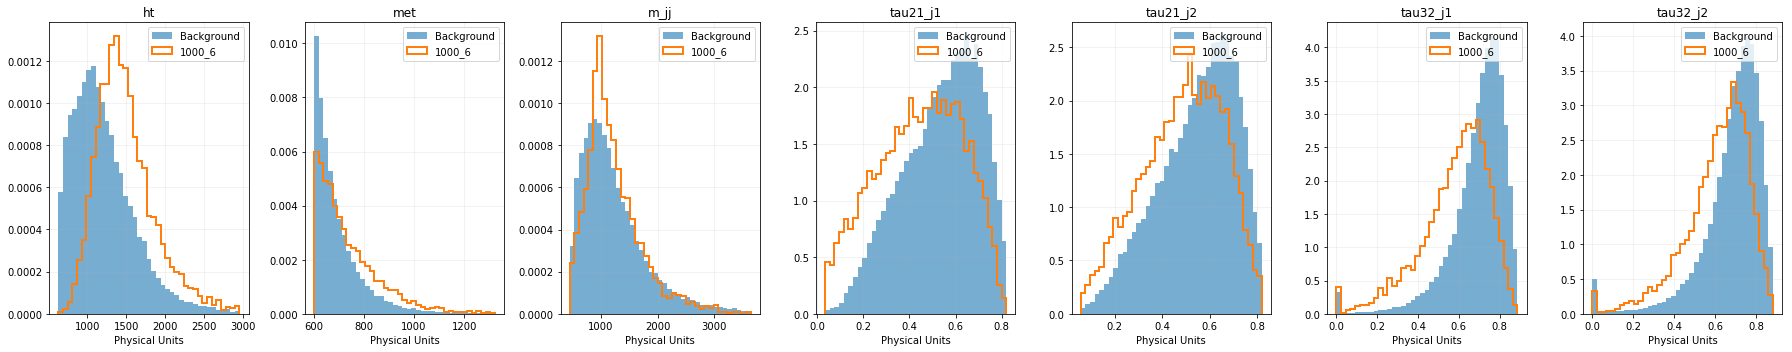

Plotting in PHYSICAL units (Inverse Scaled).


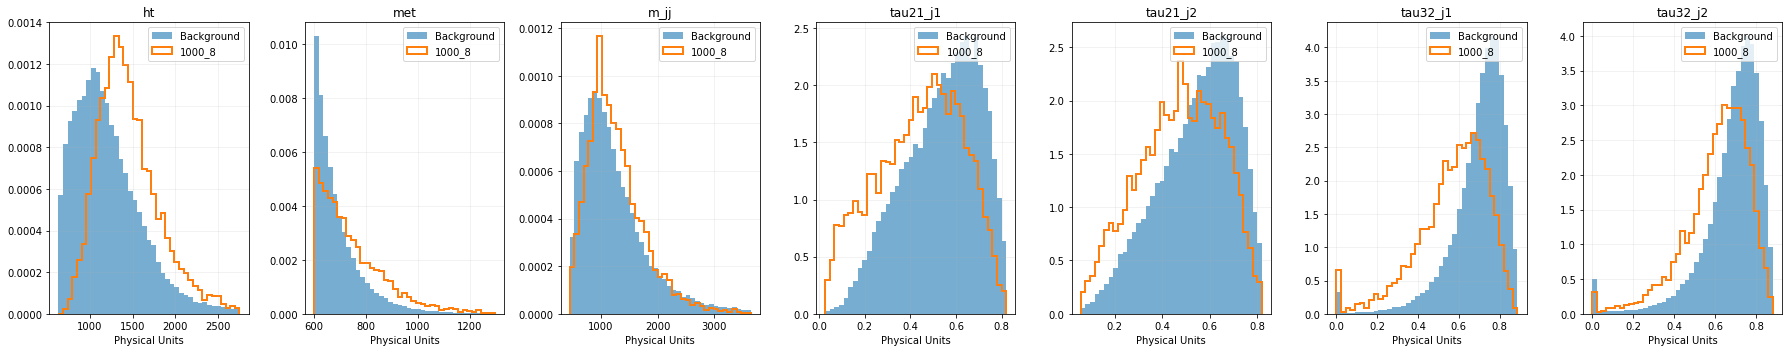

Plotting in PHYSICAL units (Inverse Scaled).


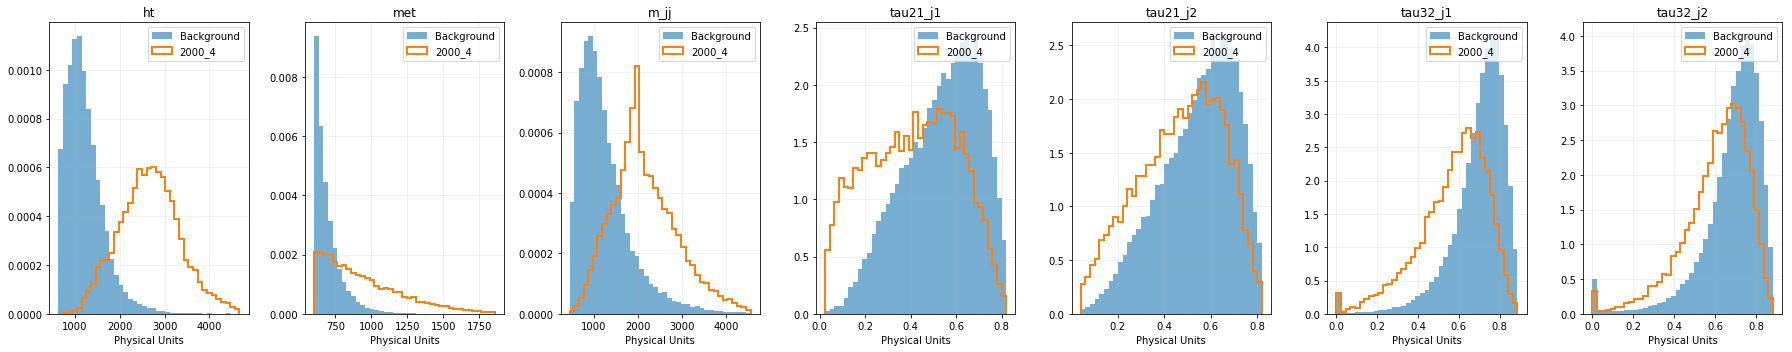

Plotting in PHYSICAL units (Inverse Scaled).


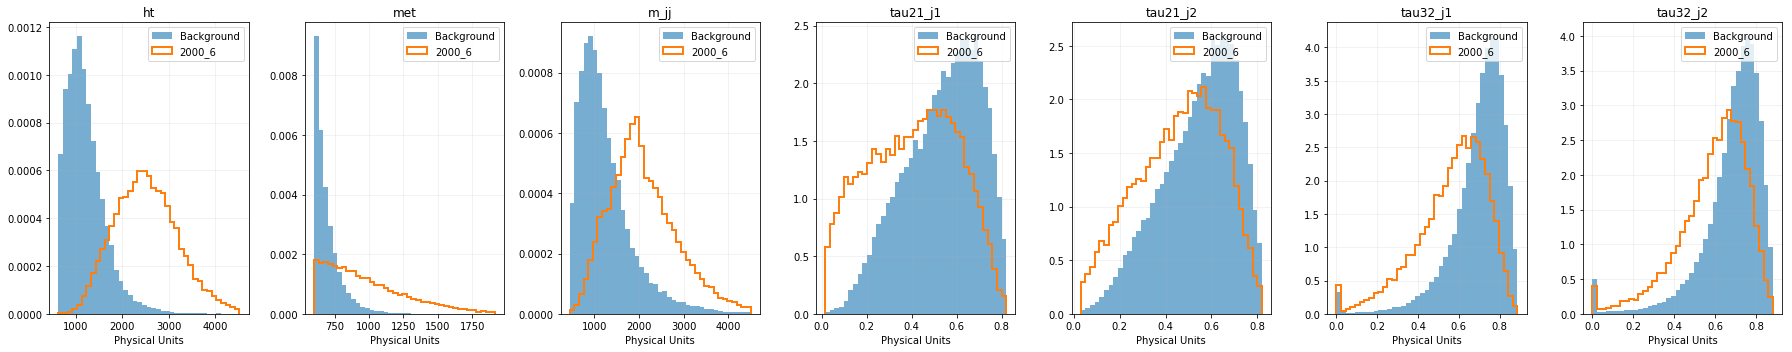

Plotting in PHYSICAL units (Inverse Scaled).


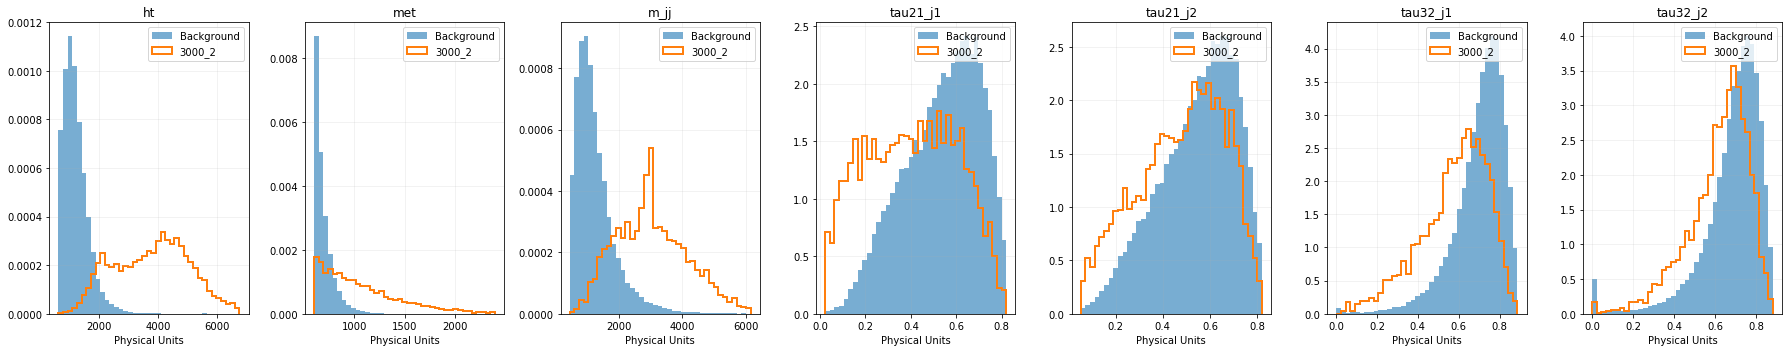

Plotting in PHYSICAL units (Inverse Scaled).


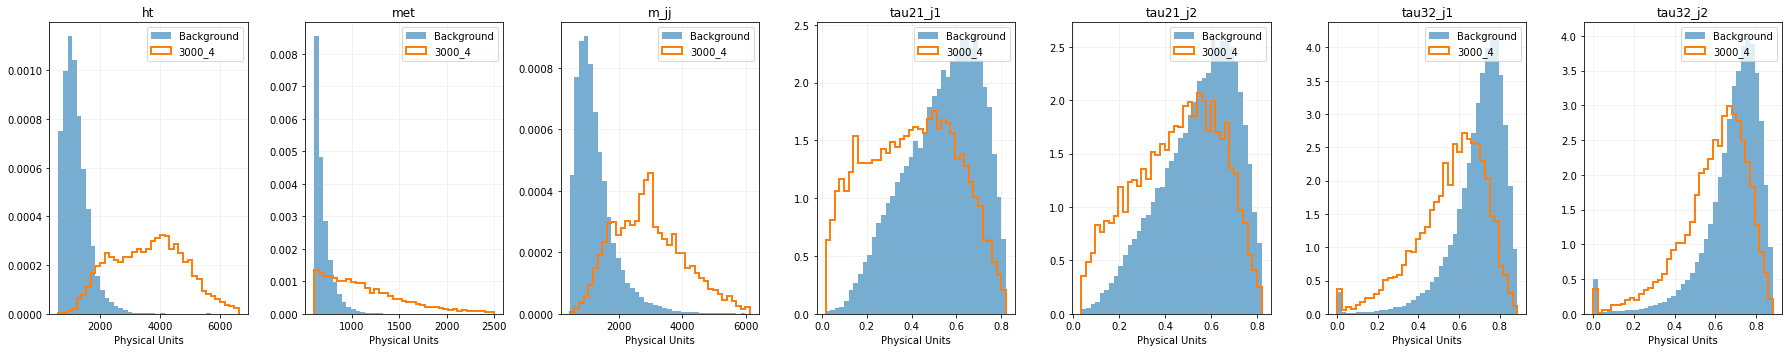

In [42]:
bg_data, scaler = load_background_and_scaler()

# 2. Select a Signal to compare (e.g., Mass 1000, Lambda 2)
# Using 'atlas_r2' dictionary we created earlier
# sig_key = "1000_6"
for sig_key in signals_cut.keys():
    df_sig_to_plot = signals_cut[sig_key]
    
    plot_feature_comparison(bg_data, df_sig_to_plot, scaler, signal_label=f"{sig_key}")
# else:
    # print(f"Signal {sig_key} not found in dictionary.")

In [43]:

datasets = [f"Data0{i}" for i in range(1, 6)]
model_paths = {}
for d in datasets:
    model_paths[d] = sorted(glob.glob(f"{MODEL_BASE_PATH}/model_reweight_SR_{d}_MC*run*.pt"))

evaluation_results = {}

# Iterate over Datasets (Data01, Data02...)
for dataset, paths in model_paths.items():
    print(f"\n=== Evaluating Dataset: {dataset} ===")
    evaluation_results[dataset] = {}
    current_signal_dict = signals_cut
    
    for signal_mode in signals_cut.keys():
        mass, lam = signal_mode.split('_')
        mass = int(mass)
        lam = int(lam)
        print(f"   Processing Signal: Mass={mass}, Lambda={lam}")

        X_test, y_test = prepare_test_data(signals_cut[f"{signal_mode}"], bg_data, scaler)
        X_input = X_test[:, N_CONTEXT:] 
        
        aucs = []
        maxsics = []
        
        # Run Ensemble of Models
        for model_path in paths[:20]: # Limit to 20 runs
            # Load Model
            try:
                net = torch.load(model_path, map_location=DEVICE, weights_only=False)
                net.to(DEVICE)
                net.model.eval()
                with torch.no_grad():
                    scores = net.evaluation(X_input)
                    scores = np.squeeze(scores)

                auc = roc_auc_score(y_test, scores)
                msic = calculate_max_sic(y_test, scores)
                
                aucs.append(auc)
                maxsics.append(msic)
                
            except Exception as e:
                print(f"      Error loading {model_path}: {e}")
        
        # Save results
        evaluation_results[dataset][signal_mode] = {
            'mean_auc': np.mean(aucs),
            'std_auc': np.std(aucs),
            'mean_maxsic': np.mean(maxsics),
            'raw_aucs': aucs
        }
        
        print(f"      -> Mean AUC: {np.mean(aucs):.4f} | Mean MaxSIC: {np.mean(maxsics):.4f}")

print("\nEvaluation Complete.")


=== Evaluating Dataset: Data01 ===
   Processing Signal: Mass=1000, Lambda=6
   Shape check: Signal (Raw): 47689 -> (Masked): 5901
      -> Mean AUC: 0.5466 | Mean MaxSIC: 1.0018
   Processing Signal: Mass=1000, Lambda=8
   Shape check: Signal (Raw): 33334 -> (Masked): 5640
      -> Mean AUC: 0.5298 | Mean MaxSIC: 1.0017
   Processing Signal: Mass=2000, Lambda=4
   Shape check: Signal (Raw): 44239 -> (Masked): 15543
      -> Mean AUC: 0.1966 | Mean MaxSIC: 1.0003
   Processing Signal: Mass=2000, Lambda=6
   Shape check: Signal (Raw): 40279 -> (Masked): 20341
      -> Mean AUC: 0.2203 | Mean MaxSIC: 1.0002
   Processing Signal: Mass=3000, Lambda=2
   Shape check: Signal (Raw): 20713 -> (Masked): 4043
      -> Mean AUC: 0.1100 | Mean MaxSIC: 1.0002
   Processing Signal: Mass=3000, Lambda=4
   Shape check: Signal (Raw): 18796 -> (Masked): 7773
      -> Mean AUC: 0.1172 | Mean MaxSIC: 1.0002

=== Evaluating Dataset: Data02 ===
   Processing Signal: Mass=1000, Lambda=6
   Shape check: Sign

In [44]:
def plot_performance_summary(results, dataset_name='Data01'):
    """Plots AUC vs Mass for different Lambda values."""
    data = results[dataset_name]
    
    # Reorganize data for plotting
    plot_data = {} # {Lambda: ([Masses], [AUCs])}
    
    for (mass, lam), metrics in data.items():
        if lam not in plot_data:
            plot_data[lam] = ([], [])
        plot_data[lam][0].append(mass)
        plot_data[lam][1].append(metrics['mean_auc'])
        
    plt.figure(figsize=(10, 6))
    
    for lam, (masses, aucs) in plot_data.items():
        # Sort by mass
        sorted_pairs = sorted(zip(masses, aucs))
        m_sorted = [x[0] for x in sorted_pairs]
        a_sorted = [x[1] for x in sorted_pairs]
        
        plt.plot(m_sorted, a_sorted, marker='o', label=f"Lambda = {lam}")
        
    plt.xlabel("Dark Meson Mass [GeV]")
    plt.ylabel("Mean AUC")
    plt.title(f"Classifier Performance - {dataset_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage
plot_performance_summary(evaluation_results, 'Data02')

ValueError: too many values to unpack (expected 2)